![Logo Javeriana](https://images.seeklogo.com/logo-png/11/1/pontificia-universidad-javeriana-logo-png_seeklogo-110703.png)

## Nombres:
- Gabriel Jaramillo Cuberos (Id: 20529022)
- Samuel Beltrán Martínez (Id: 20524509)
- David Vargas (Id: 20485686)
- Juan Felipe Gómez López (Id: 20553416)
- Sara Pulgarín (Id: 20491129)
- Juan Camilo Delgado (Id: 20506996)

### Primera entrega del proyecto

*Materia:* Procesamiento de Datos (1255)

*Tema:* Consultoría Nueva York.

*Descripción:* En este cuaderno se realiza el bono consulta climatica con API key

*Nombre del fichero:* 02_Bono_ClimaAPI.ipynb

## 1. Identificación de la API
### Ubicación consultada

La API trabaja con coordenadas geográficas (`lat`, `lon`). Se consulta una sola ubicación:

- Nueva York (estado de New York, EE. UU.): 40.7128, -74.0060

En el código, el campo `departamento` guarda el estado al que pertenece la ciudad.
Permite analizar la evolución del clima de Nueva York durante 5 días (datos cada 3 horas) y compararla con la condición actual.|

## 2. Preparación del entorno


In [1]:
import os
import json
import time
from datetime import datetime, timezone

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## 3. Consulta a la API y descarga de los datos

Para Nueva York se hacen dos consultas: la condición actual (`/weather`) y el pronóstico de 5 días cada 3 horas (`/forecast`). En total son 2 llamadas, muy por debajo del límite de 60 por minuto del plan gratuito.

Las respuestas completas se guardan en un archivo JSON local para trabajar sin volver a consultar la API.


In [2]:
API_KEY = "71c6b86a29cf53c7dd6f04fa0c97285c"

API_KEY = API_KEY.strip() or os.environ.get("OPENWEATHER_API_KEY", "").strip()
if not API_KEY:
    try:
        from google.colab import userdata
        API_KEY = (userdata.get("OPENWEATHER_API_KEY") or "").strip()
    except Exception:
        pass
if not API_KEY:
    raise ValueError("Falta la llave: pega tu API key entre comillas en la variable API_KEY")

URL_ACTUAL = "https://api.openweathermap.org/data/2.5/weather"
URL_PRONOSTICO = "https://api.openweathermap.org/data/2.5/forecast"
UNIDADES = "metric"
IDIOMA = "es"
CIUDADES = {
    "Nueva York": {"departamento": "New York", "lat": 40.7128, "lon": -74.0060},
}


def consultar(url, parametros, reintentos=3):
    for intento in range(1, reintentos + 1):
        respuesta = requests.get(url, params=parametros, timeout=60)
        if respuesta.status_code == 429:
            print(f"  Limite de peticiones alcanzado (intento {intento}/{reintentos}); esperando...")
            time.sleep(10 * intento)
            continue
        if respuesta.status_code == 401:
            raise PermissionError("Error 401: la API key no es valida o todavia no esta activa")
        respuesta.raise_for_status()
        return respuesta.json()
    raise RuntimeError("La API siguio respondiendo 429 (demasiadas peticiones). Intenta de nuevo mas tarde.")


os.makedirs("datos", exist_ok=True)
ruta_local = os.path.join("datos", "respuestas_openweather.json")

respuestas = {
    "consultado_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "unidades": UNIDADES,
    "ciudades": CIUDADES,
    "actual": {},
    "pronostico": {},
}

for ciudad, info in CIUDADES.items():
    parametros = {"lat": info["lat"], "lon": info["lon"], "units": UNIDADES, "lang": IDIOMA, "appid": API_KEY}

    respuestas["actual"][ciudad] = consultar(URL_ACTUAL, parametros)
    respuestas["pronostico"][ciudad] = consultar(URL_PRONOSTICO, parametros)

    print(f"{ciudad}: condicion actual y {len(respuestas['pronostico'][ciudad]['list'])} registros de pronostico")
    time.sleep(0.3)

with open(ruta_local, "w", encoding="utf-8") as archivo:
    json.dump(respuestas, archivo, ensure_ascii=False, indent=2)

print()
print("Consulta completada")
print("Tamanio del archivo guardado en bytes:", os.path.getsize(ruta_local))

Nueva York: condicion actual y 40 registros de pronostico

Consulta completada
Tamanio del archivo guardado en bytes: 37242


## 4. Carga y exploración inicial de los datos


In [3]:
with open(ruta_local, encoding="utf-8") as archivo:
    datos_json = json.load(archivo)

ciudades = datos_json["ciudades"]


def resumir(obj, nombre="raiz", nivel=0, max_nivel=3):
    sangria = "  " * nivel
    if isinstance(obj, dict):
        print(f"{sangria}{nombre}: dict con {len(obj)} claves")
        if nivel < max_nivel:
            for k, v in list(obj.items())[:16]:
                resumir(v, str(k), nivel + 1, max_nivel)
    elif isinstance(obj, list):
        print(f"{sangria}{nombre}: lista de {len(obj)} elementos ({type(obj[0]).__name__ if obj else 'vacia'})")
        if obj and nivel < max_nivel:
            resumir(obj[0], nombre + "[0]", nivel + 1, max_nivel)
    else:
        print(f"{sangria}{nombre}: {type(obj).__name__} = {str(obj)[:40]}")


primera = list(ciudades)[0]
print("Ubicacion consultada:", list(ciudades))
print()
print(f"Estructura de /weather para {primera}:")
resumir(datos_json["actual"][primera])
print()
print(f"Estructura de /forecast para {primera}:")
resumir(datos_json["pronostico"][primera])

Ubicacion consultada: ['Nueva York']

Estructura de /weather para Nueva York:
raiz: dict con 13 claves
  coord: dict con 2 claves
    lon: float = -74.0061
    lat: float = 40.7132
  weather: lista de 1 elementos (dict)
    weather[0]: dict con 4 claves
      id: int = 804
      main: str = Clouds
      description: str = nubes
      icon: str = 04d
  base: str = stations
  main: dict con 8 claves
    temp: float = 24.43
    feels_like: float = 24.52
    temp_min: float = 22.75
    temp_max: float = 25.64
    pressure: int = 1018
    humidity: int = 61
    sea_level: int = 1018
    grnd_level: int = 1014
  visibility: int = 10000
  wind: dict con 2 claves
    speed: float = 4.12
    deg: int = 310
  clouds: dict con 1 claves
    all: int = 95
  dt: int = 1790797253
  sys: dict con 5 claves
    type: int = 1
    id: int = 4610
    country: str = US
    sunrise: int = 1790765481
    sunset: int = 1790808032
  timezone: int = -14400
  id: int = 5128581
  name: str = New York
  cod: int = 

## 5. Conversión de las respuestas en tablas


Se construyen dos tablas en bruto: una con la condición actual (1 fila) y otra con el pronóstico cada 3 horas (40 filas).

In [4]:
def tabla_actual(ciudad, respuesta):
    tabla = pd.json_normalize([respuesta])
    tabla.insert(0, "ciudad", ciudad)
    tabla.insert(1, "departamento", ciudades[ciudad]["departamento"])
    tabla["desfase_s"] = respuesta.get("timezone", 0)
    return tabla


def tabla_pronostico(ciudad, respuesta):
    tabla = pd.json_normalize(respuesta["list"])
    tabla.insert(0, "ciudad", ciudad)
    tabla.insert(1, "departamento", ciudades[ciudad]["departamento"])
    tabla["desfase_s"] = respuesta.get("city", {}).get("timezone", 0)
    return tabla


df_actual_bruto = pd.concat(
    [tabla_actual(c, r) for c, r in datos_json["actual"].items()], ignore_index=True)

df_pronostico_bruto = pd.concat(
    [tabla_pronostico(c, r) for c, r in datos_json["pronostico"].items()], ignore_index=True)

print("Condicion actual (bruto):", df_actual_bruto.shape)
print("Pronostico cada 3 horas (bruto):", df_pronostico_bruto.shape)
print()
print("Columnas del pronostico:")
print(list(df_pronostico_bruto.columns))

Condicion actual (bruto): (1, 29)
Pronostico cada 3 horas (bruto): (40, 24)

Columnas del pronostico:
['ciudad', 'departamento', 'dt', 'weather', 'visibility', 'pop', 'dt_txt', 'main.temp', 'main.feels_like', 'main.temp_min', 'main.temp_max', 'main.pressure', 'main.sea_level', 'main.grnd_level', 'main.humidity', 'main.temp_kf', 'main.dew_point', 'clouds.all', 'wind.speed', 'wind.deg', 'wind.gust', 'sys.pod', 'rain.3h', 'desfase_s']


## 6. Selección de columnas relevantes y limpieza

Se conservan las variables climáticas de interés

In [5]:
def serie(df, *candidatas):
    '''Devuelve la columna numerica; si hay varias candidatas las combina, y si ninguna existe devuelve NaN.'''
    existentes = [pd.to_numeric(df[c], errors="coerce") for c in candidatas if c in df.columns]
    if not existentes:
        return pd.Series(float("nan"), index=df.index, dtype="float64")
    resultado = existentes[0]
    for otra in existentes[1:]:
        resultado = resultado.fillna(otra)
    return resultado


def unix_a_local(segundos, desfase):
    utc = pd.to_datetime(segundos, unit="s", utc=True)
    return (utc + pd.to_timedelta(desfase, unit="s")).dt.tz_localize(None)


def primer_clima(lista, campo):
    return lista[0].get(campo) if isinstance(lista, list) and lista else None


# ---------- Condicion actual ----------
a = df_actual_bruto
df_actual = pd.DataFrame({
    "ciudad": a["ciudad"],
    "departamento": a["departamento"],
    "fecha_hora": unix_a_local(a["dt"], a["desfase_s"]),
    "temp_c": serie(a, "main.temp"),
    "sensacion_c": serie(a, "main.feels_like"),
    "temp_min_c": serie(a, "main.temp_min"),
    "temp_max_c": serie(a, "main.temp_max"),
    "presion_hpa": serie(a, "main.pressure"),
    "humedad_pct": serie(a, "main.humidity"),
    "nubosidad_pct": serie(a, "clouds.all"),
    "visibilidad_m": serie(a, "visibility"),
    "viento_ms": serie(a, "wind.speed"),
    "viento_grados": serie(a, "wind.deg"),
    "lluvia_mm": serie(a, "rain.1h").fillna(0),
    "condicion": a["weather"].map(lambda w: primer_clima(w, "main")),
    "descripcion": a["weather"].map(lambda w: primer_clima(w, "description")),
    "amanecer": unix_a_local(serie(a, "sys.sunrise"), a["desfase_s"]),
    "atardecer": unix_a_local(serie(a, "sys.sunset"), a["desfase_s"]),
})

# ---------- Pronostico cada 3 horas ----------
p = df_pronostico_bruto
df_pronostico = pd.DataFrame({
    "ciudad": p["ciudad"],
    "departamento": p["departamento"],
    "fecha_hora": unix_a_local(p["dt"], p["desfase_s"]),
    "temp_c": serie(p, "main.temp"),
    "sensacion_c": serie(p, "main.feels_like"),
    "temp_min_c": serie(p, "main.temp_min"),
    "temp_max_c": serie(p, "main.temp_max"),
    "presion_hpa": serie(p, "main.pressure"),
    "humedad_pct": serie(p, "main.humidity"),
    "nubosidad_pct": serie(p, "clouds.all"),
    "viento_ms": serie(p, "wind.speed"),
    "racha_ms": serie(p, "wind.gust"),
    "visibilidad_m": serie(p, "visibility"),
    "prob_lluvia_pct": serie(p, "pop") * 100,
    "lluvia_mm": serie(p, "rain.3h").fillna(0),
    "condicion": p["weather"].map(lambda w: primer_clima(w, "main")),
    "descripcion": p["weather"].map(lambda w: primer_clima(w, "description")),
})

df_pronostico = (df_pronostico.drop_duplicates(subset=["ciudad", "fecha_hora"])
                              .sort_values(["ciudad", "fecha_hora"]).reset_index(drop=True))

print("Condicion actual:")
print(df_actual[["ciudad", "fecha_hora", "temp_c", "sensacion_c", "humedad_pct", "descripcion"]])
print()
print("Pronostico cada 3 horas (primeras filas):")
df_pronostico.head(10)

Condicion actual:
       ciudad          fecha_hora  temp_c  sensacion_c  humedad_pct  \
0  Nueva York 2026-09-30 15:40:53   24.43        24.52           61   

  descripcion  
0       nubes  

Pronostico cada 3 horas (primeras filas):


,ciudad,departamento,fecha_hora,temp_c,sensacion_c,temp_min_c,temp_max_c,presion_hpa,humedad_pct,nubosidad_pct,viento_ms,racha_ms,visibilidad_m,prob_lluvia_pct,lluvia_mm,condicion,descripcion
0,Nueva York,New York,2026-09-30 17:00:00,24.45,24.54,22.38,24.45,1018,61,69,1.97,4.27,10000,0.0,0.0,Clouds,muy nuboso
1,Nueva York,New York,2026-09-30 20:00:00,22.59,22.71,18.87,22.59,1018,69,75,1.93,3.83,10000,0.0,0.0,Clouds,muy nuboso
2,Nueva York,New York,2026-09-30 23:00:00,19.70,19.89,17.32,19.70,1019,83,89,1.90,3.58,10000,0.0,0.0,Clouds,nubes
3,Nueva York,New York,2026-10-01 02:00:00,17.62,17.89,17.62,17.62,1019,94,100,1.94,3.55,10000,0.0,0.0,Clouds,nubes
4,Nueva York,New York,2026-10-01 05:00:00,17.08,17.32,17.08,17.08,1019,95,93,1.83,3.44,10000,28.0,0.0,Clouds,nubes
5,Nueva York,New York,2026-10-01 08:00:00,18.74,19.10,18.74,18.74,1019,93,95,2.31,4.29,10000,0.0,0.0,Clouds,nubes
6,Nueva York,New York,2026-10-01 11:00:00,18.91,19.15,18.91,18.91,1019,88,100,2.05,5.00,10000,0.0,0.0,Clouds,nubes
7,Nueva York,New York,2026-10-01 14:00:00,20.74,20.93,20.74,20.74,1017,79,29,2.73,5.79,10000,0.0,0.0,Clouds,nubes dispersas
8,Nueva York,New York,2026-10-01 17:00:00,22.97,23.31,22.97,22.97,1016,76,20,2.17,4.70,10000,0.0,0.0,Clouds,algo de nubes
9,Nueva York,New York,2026-10-01 20:00:00,20.62,20.98,20.62,20.62,1015,86,64,2.33,4.27,10000,0.0,0.0,Clouds,muy nuboso


## 7. Resumen diario del pronóstico

El pronóstico llega cada 3 horas (hasta 8 registros por día). Para compararlo por día se agrupa por fecha local y se calcula:

- **Temperatura:** media del día, mínima y máxima.
- **Humedad, presión, nubosidad y viento:** promedio del día.
- **Probabilidad de lluvia:** el valor máximo del día.
- **Lluvia:** suma de los milímetros de los registros del día.
- **Condición dominante:** la más frecuente entre los registros.



In [6]:
df_pronostico["fecha"] = df_pronostico["fecha_hora"].dt.normalize()


def valor_mas_frecuente(serie_texto):
    moda = serie_texto.mode()
    return moda.iat[0] if not moda.empty else None


df_diario = (
    df_pronostico.groupby(["ciudad", "departamento", "fecha"])
    .agg(
        n_registros=("fecha_hora", "count"),
        temp_media_c=("temp_c", "mean"),
        temp_min_c=("temp_min_c", "min"),
        temp_max_c=("temp_max_c", "max"),
        humedad_media_pct=("humedad_pct", "mean"),
        presion_media_hpa=("presion_hpa", "mean"),
        nubosidad_media_pct=("nubosidad_pct", "mean"),
        viento_medio_ms=("viento_ms", "mean"),
        prob_lluvia_max_pct=("prob_lluvia_pct", "max"),
        lluvia_total_mm=("lluvia_mm", "sum"),
        condicion_dominante=("condicion", valor_mas_frecuente),
    )
    .reset_index()
)
df_diario["dia_completo"] = df_diario["n_registros"] == 8
columnas_numericas = df_diario.select_dtypes("number").columns
df_diario[columnas_numericas] = df_diario[columnas_numericas].round(2)

df_diario

,ciudad,departamento,fecha,n_registros,temp_media_c,temp_min_c,temp_max_c,humedad_media_pct,presion_media_hpa,nubosidad_media_pct,viento_medio_ms,prob_lluvia_max_pct,lluvia_total_mm,condicion_dominante,dia_completo
0,Nueva York,New York,2026-09-30,3,22.25,17.32,24.45,71.00,1018.33,77.67,1.93,0.0,0.00,Clouds,False
1,Nueva York,New York,2026-10-01,8,19.68,17.08,22.97,86.88,1017.50,63.75,2.27,28.0,0.00,Clouds,True
2,Nueva York,New York,2026-10-02,8,21.85,16.65,27.54,77.00,1014.12,68.12,3.14,84.0,1.82,Clouds,True
3,Nueva York,New York,2026-10-03,8,17.50,14.35,21.49,69.12,1022.00,27.25,2.09,20.0,0.12,Clear,True
4,Nueva York,New York,2026-10-04,8,16.24,12.99,19.32,76.00,1022.88,71.75,1.66,0.0,0.00,Clouds,True
5,Nueva York,New York,2026-10-05,5,17.61,15.57,22.95,82.00,1014.80,71.80,1.27,20.0,0.18,Clouds,False


## 8. Verificación de valores faltantes, duplicados y tipos de datos, así mismo tabla final



In [7]:
tabla_final = df_diario.sort_values("fecha").reset_index(drop=True)

print("Valores faltantes por columna:")
print(tabla_final.isnull().sum())
print()

print("Numero de registros duplicados (ciudad y fecha):")
print(tabla_final.duplicated(subset=["ciudad", "fecha"]).sum())
print()

print("Tipos de datos por columna:")
print(tabla_final.dtypes)
print()

print("Numero de ubicaciones encontradas:", tabla_final["ciudad"].nunique())
print("Se espera exactamente 1 ubicacion (Nueva York)")
print("Registros de pronostico cada 3 horas:", len(df_pronostico), "(se esperan 40)")
print()
print("Dias de pronostico (total y completos):")
print(tabla_final.groupby("ciudad").agg(dias=("fecha", "count"),
                                        completos=("dia_completo", "sum"),
                                        desde=("fecha", "min"), hasta=("fecha", "max")))
print()

df_actual.to_csv(os.path.join("datos", "clima_ny_actual.csv"), index=False, encoding="utf-8")
df_pronostico.to_csv(os.path.join("datos", "clima_ny_pronostico_3h.csv"), index=False, encoding="utf-8")
df_diario.to_csv(os.path.join("datos", "clima_ny_diario.csv"), index=False, encoding="utf-8")
print("Tablas guardadas en la carpeta datos/")

tabla_final

Valores faltantes por columna:
ciudad                 0
departamento           0
fecha                  0
n_registros            0
temp_media_c           0
temp_min_c             0
temp_max_c             0
humedad_media_pct      0
presion_media_hpa      0
nubosidad_media_pct    0
viento_medio_ms        0
prob_lluvia_max_pct    0
lluvia_total_mm        0
condicion_dominante    0
dia_completo           0
dtype: int64

Numero de registros duplicados (ciudad y fecha):
0

Tipos de datos por columna:
ciudad                           str
departamento                     str
fecha                  datetime64[s]
n_registros                    int64
temp_media_c                 float64
temp_min_c                   float64
temp_max_c                   float64
humedad_media_pct            float64
presion_media_hpa            float64
nubosidad_media_pct          float64
viento_medio_ms              float64
prob_lluvia_max_pct          float64
lluvia_total_mm              float64
condicion_dominante

,ciudad,departamento,fecha,n_registros,temp_media_c,temp_min_c,temp_max_c,humedad_media_pct,presion_media_hpa,nubosidad_media_pct,viento_medio_ms,prob_lluvia_max_pct,lluvia_total_mm,condicion_dominante,dia_completo
0,Nueva York,New York,2026-09-30,3,22.25,17.32,24.45,71.00,1018.33,77.67,1.93,0.0,0.00,Clouds,False
1,Nueva York,New York,2026-10-01,8,19.68,17.08,22.97,86.88,1017.50,63.75,2.27,28.0,0.00,Clouds,True
2,Nueva York,New York,2026-10-02,8,21.85,16.65,27.54,77.00,1014.12,68.12,3.14,84.0,1.82,Clouds,True
3,Nueva York,New York,2026-10-03,8,17.50,14.35,21.49,69.12,1022.00,27.25,2.09,20.0,0.12,Clear,True
4,Nueva York,New York,2026-10-04,8,16.24,12.99,19.32,76.00,1022.88,71.75,1.66,0.0,0.00,Clouds,True
5,Nueva York,New York,2026-10-05,5,17.61,15.57,22.95,82.00,1014.80,71.80,1.27,20.0,0.18,Clouds,False


In [8]:
df_actual.set_index("ciudad").T

ciudad,Nueva York
departamento,New York
fecha_hora,2026-09-30 15:40:53
temp_c,24.43
sensacion_c,24.52
temp_min_c,22.75
temp_max_c,25.64
presion_hpa,1018
humedad_pct,61
nubosidad_pct,95
visibilidad_m,10000


## 9. Visualización

Se grafican los datos extraídos de Nueva York:

1. **Temperatura y sensación térmica** durante el pronóstico (líneas, cada 3 horas).
2. **Temperatura mínima, media y máxima por día** (barras y línea, solo con días completos).
3. **Probabilidad de lluvia** cada 3 horas (barras), junto con los milímetros esperados si hay lluvia en el pronóstico.

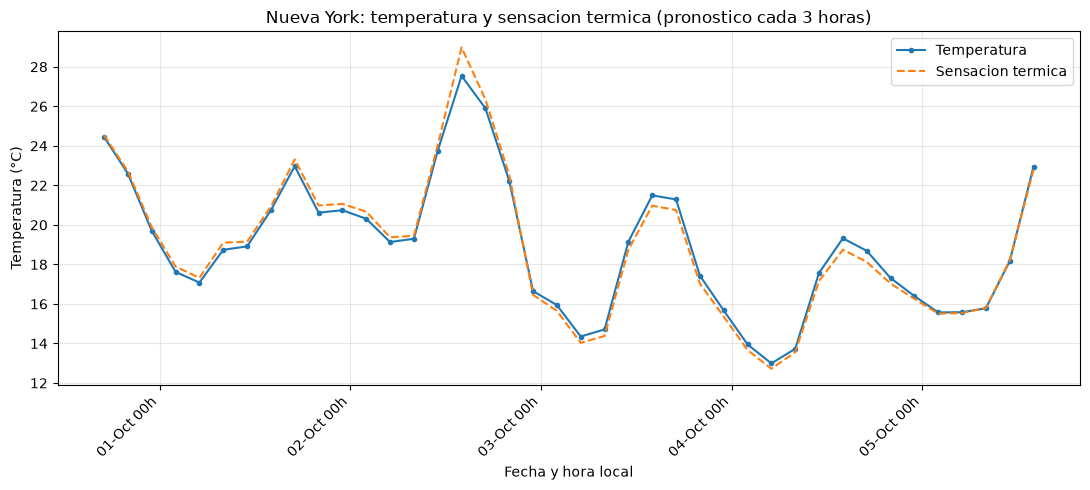

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df_pronostico["fecha_hora"], df_pronostico["temp_c"], marker="o", markersize=3, label="Temperatura")
ax.plot(df_pronostico["fecha_hora"], df_pronostico["sensacion_c"], linestyle="--", label="Sensacion termica")
ax.set_title("Nueva York: temperatura y sensacion termica (pronostico cada 3 horas)")
ax.set_xlabel("Fecha y hora local")
ax.set_ylabel("Temperatura (°C)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %Hh"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

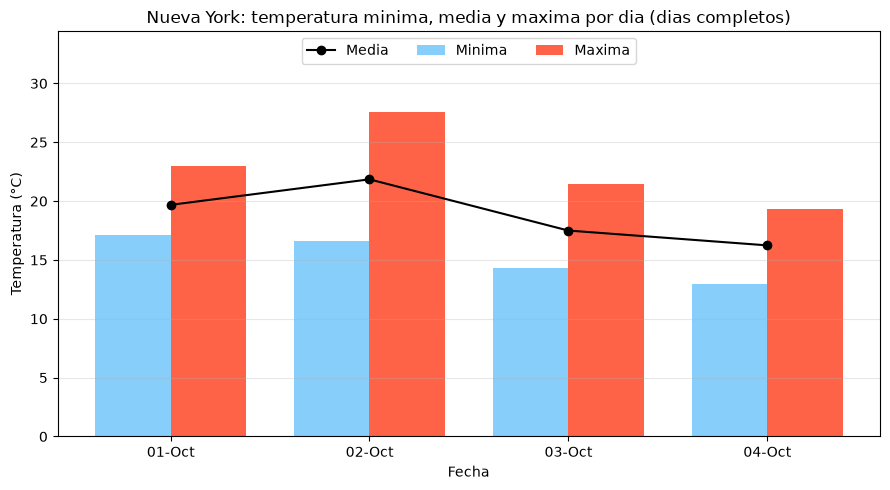

In [10]:
completos = df_diario[df_diario["dia_completo"]].reset_index(drop=True)
posiciones = list(range(len(completos)))
ancho = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - ancho / 2 for i in posiciones], completos["temp_min_c"], ancho, label="Minima", color="lightskyblue")
ax.bar([i + ancho / 2 for i in posiciones], completos["temp_max_c"], ancho, label="Maxima", color="tomato")
ax.plot(posiciones, completos["temp_media_c"], marker="o", color="black", label="Media")
ax.set_xticks(posiciones)
ax.set_xticklabels([f.strftime("%d-%b") for f in completos["fecha"]])
ax.set_title("Nueva York: temperatura minima, media y maxima por dia (dias completos)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, completos["temp_max_c"].max() * 1.25)      # espacio libre para la leyenda
ax.legend(loc="upper center", ncol=3)
plt.tight_layout()
plt.show()

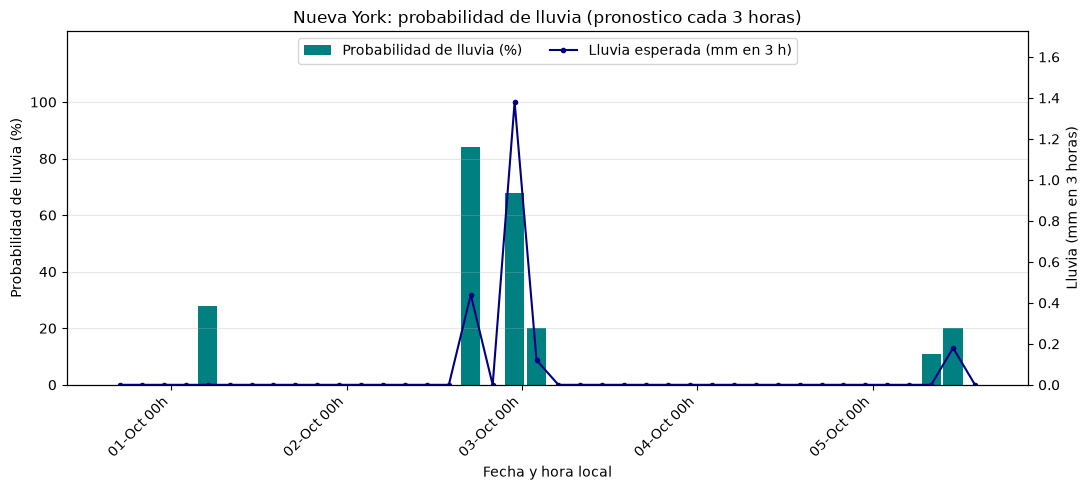

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(df_pronostico["fecha_hora"], df_pronostico["prob_lluvia_pct"], width=0.11, color="teal",
       label="Probabilidad de lluvia (%)")
ax.set_title("Nueva York: probabilidad de lluvia (pronostico cada 3 horas)")
ax.set_xlabel("Fecha y hora local")
ax.set_ylabel("Probabilidad de lluvia (%)")
ax.set_ylim(0, 125)
ax.set_yticks(range(0, 101, 20))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %Hh"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
manijas, etiquetas = ax.get_legend_handles_labels()

if df_pronostico["lluvia_mm"].sum() > 0:
    ax2 = ax.twinx()
    ax2.plot(df_pronostico["fecha_hora"], df_pronostico["lluvia_mm"], color="navy", marker="o",
             markersize=3, label="Lluvia esperada (mm en 3 h)")
    ax2.set_ylabel("Lluvia (mm en 3 horas)")
    ax2.set_ylim(0, df_pronostico["lluvia_mm"].max() * 1.25)
    manijas2, etiquetas2 = ax2.get_legend_handles_labels()
    manijas, etiquetas = manijas + manijas2, etiquetas + etiquetas2
else:
    print("El pronostico no incluye lluvia en estos 5 dias (lluvia esperada = 0 mm).")

ax.legend(manijas, etiquetas, loc="upper center", ncol=2)

plt.tight_layout()
plt.show()